In [2]:
from src.models import *
import src.utils as utils
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import mlflow

import pickle

from mlflow.tracking import MlflowClient

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [5]:
def get_data():
    global label_map
    data_dir = r'F:\thesis\Articles\2nd\cod\Data'
    file_name = 'input.pkl'
    file_name_label = 'output.pkl'
    file_path = os.path.join(data_dir, file_name)
    file_path_label = os.path.join(data_dir, file_name_label)

    data = utils.read_pkl(file_path)
    label = utils.read_pkl(file_path_label)

    label_encoded, label_map = utils.label_encoder(label)

    X_train, X_test, y_train, y_test = train_test_split(
        data,
        label_encoded,
        test_size = 0.2,
        random_state = 69,
        shuffle = True,
    )

    (X_train_scaled, X_test_scaled),scaler_list = utils.scale_it(X_train, X_test)

    X_train_scaled_tensor, y_train_tensor = utils.tensor_it(X_train_scaled,y_train)
    X_test_scaled_tensor, y_test_tensor = utils.tensor_it(X_test_scaled,y_test)

    return X_train_scaled_tensor, y_train_tensor, X_test_scaled_tensor, y_test_tensor, label_map


## AUX

In [4]:

art_dir2 = r'F:\thesis\Articles\2nd\mlruns-20250726T033440Z-1-001\mlruns\994478961421787748\5945e3b605184dd4866fcccf6edc6ace\artifacts'
art_dir = r'F:\thesis\Articles\2nd\mlruns-20250726T033440Z-1-001\mlruns\623922822895938578\26f61da787ea448cb55e49f781245ffe\artifacts'
weight_dir = os.path.join(art_dir,'test_weight.pth')
weight_dir2 = os.path.join(art_dir2,'test_weight.pth')

X, y, X_t, y_t, lm = get_data()
print(X.shape + X_t.shape)

model = utils.load_model(Model2(26), weight_dir)
model2 = utils.load_model(Network(26), weight_dir2)

y_hat = utils.model_forward(model, X_t, y_t)
y_hat2 = utils.model_forward(model2, X_t, y_t)

pred_dic2 = utils.pred_mat(X_t, y_t, y_hat2, list(lm.values()))

torch.Size([3940, 5, 1024, 2, 985, 5, 1024, 2])


f:\thesis\Articles\2nd\code\src\utils.py:378: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen/native/IndexingUtils.h:30.)
  pred_dic[f'{true_name}_{pred_name}'] = X[mask, 2, :, :]


In [6]:
# X_train_scaled_tensor = utils.read_pkl('Data/features_train_all.pkl')
X_test_scaled_tensor = utils.read_pkl('Data/features_test.pkl')
# y_train_tensor = utils.read_pkl('Data/y_train_all.pkl')
y_test_tensor = utils.read_pkl('Data/y_test.pkl')

model_trans = utils.load_model(
    TransformerClassifier(input_dim=1050, d_model=1050*5, nhead=5, num_classes=26),
    r'F:\thesis\Articles\2nd\code\Data\test_weight_transformer.pth'
)
y_hat_trans = utils.model_forward(
    model_trans,
    X_test_scaled_tensor,
    y_test_tensor
)

In [7]:
cm_usual = utils.calc_cm(model2, X_t, y_t)
cm_trans = utils.calc_cm(model_trans, X_test_scaled_tensor, y_test_tensor)

In [8]:
utils.save_cm(cm_usual, list(label_map.keys()), split="Usual_Test")
utils.save_cm(cm_trans, list(label_map.keys()), split="Trans_Test")

In [10]:
print(5000 // len(np.unique(y)))

192


In [6]:
mat01=pred_dic2['0_1']
mat10=pred_dic2['1_0']
mat11 =pred_dic2['1_1']
mat00 = pred_dic2['0_0']

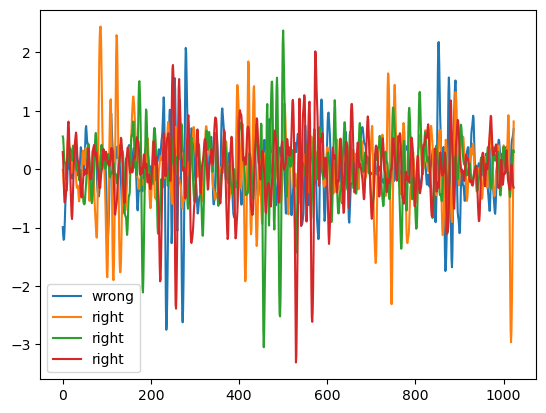

In [ ]:
plt.plot(mat10[0,:,0
], label='wrong')
plt.plot(mat11[1,:,0
], label='right')
plt.plot(mat11[2,:,0
], label='right')
plt.plot(mat11[3,:,0
], label='right')
plt.legend()

In [4]:
art_dir2 = r'F:\thesis\Articles\2nd\mlruns-20250726T033440Z-1-001\mlruns\994478961421787748\5945e3b605184dd4866fcccf6edc6ace\artifacts'
art_dir = r'F:\thesis\Articles\2nd\mlruns-20250726T033440Z-1-001\mlruns\623922822895938578\26f61da787ea448cb55e49f781245ffe\artifacts'
weight_dir = os.path.join(art_dir,'test_weight.pth')
weight_dir2 = os.path.join(art_dir2,'test_weight.pth')

model2 = utils.load_model(Network(26), weight_dir2)
label_coder = lambda x: torch.nn.functional.one_hot(x,num_classes=26)

X, y, X_t, y_t, lm = get_data()

In [8]:
features_train = torch.zeros(len(X),5,26)
features_test = torch.zeros(len(X_t),5,26)
model2.eval()
with torch.no_grad():
    for i, input_train in enumerate(X):

        output, embed = model2(input_train)
        embed = embed # Delete classifier features (keep FE features)
        output,_ = torch.max(output, 1)
        output = output.long()
        y_code = label_coder(output)
        y_code[2,:]  = 0

        # features_train[i] = torch.concat([y_code, embed], dim=1)
        features_train[i] = y_code


    for i, input_train in enumerate(X_t):

        output, embed = model2(input_train)
        embed = embed # Delete classifier features (keep FE features)
        output,_ = torch.max(output, 1)
        output = output.long()
        y_code = label_coder(output)
        y_code[2,:]  = 0

        # features_test[i] = torch.concat([y_code, embed], dim=1)
        features_test[i] = y_code

In [6]:
y_code.shape

torch.Size([5, 26])

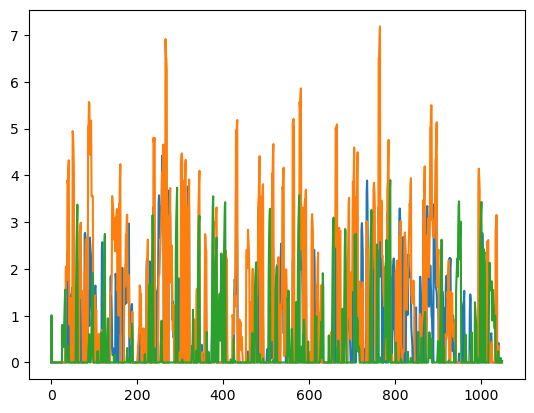

In [40]:
plt.plot(features_train[0,2,:].cpu().numpy())
plt.plot(features_train[50,2,:].cpu().numpy())
plt.plot(features_train[150,2,:].cpu().numpy())
# plt.xlim((1114-200, 1114))

In [9]:
with open('features_train_justy.pkl', 'wb') as file:
    pickle.dump(features_train, file)
with open('features_test_justy.pkl', 'wb') as file:
    pickle.dump(features_test, file)
with open('y_train_justy.pkl', 'wb') as file:
    pickle.dump(y, file)
with open('y_test_justy.pkl', 'wb') as file:
    pickle.dump(y_t, file)

train Aux model (only mode)

In [5]:
X_train_scaled_tensor = utils.read_pkl('Data/features_train.pkl')
X_test_scaled_tensor = utils.read_pkl('Data/features_test.pkl')
y_train_tensor = utils.read_pkl('Data/y_train.pkl')
y_test_tensor = utils.read_pkl('Data/y_test.pkl')

train_loader = utils.make_loader(X_train_scaled_tensor,y_train_tensor, 128)
test_loader = utils.make_loader(X_test_scaled_tensor,y_test_tensor, 128)

if mlflow.active_run():
    mlflow.end_run()

experiment_name = 'justAuxiliary'
experiment = mlflow.get_experiment_by_name(experiment_name)
if experiment is None:
    mlflow.create_experiment(experiment_name)
mlflow.set_experiment(experiment_name)

mlflow.start_run()
mlflow.log_param('label map',lm)
data = X_train_scaled_tensor
mlflow.log_param('data_shape', data.shape)
mlflow.set_tag('Describe', 'All features (CNN & MLP)')

# model = models.Model2(26).to(device)
# model = models.Network(26).to(device)
# model = Auxilixary(26).to(device)
model = TransformerClassifier(input_dim=1050*5, d_model=1050*5)
model.save_path = r'F:\thesis\Articles\2nd\code\temp\test_weight.pth'
model.patience = 50
model.best_acc = -100
model.e_ratio = 1000

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
a = utils.train_classifier(
    model,
    criterion,
    optimizer,
    train_loader,
    test_loader,
    epochs=300,
    early_stopping='val_loss',
    alpha = 0.5,
    mode = 'justaux'
)


# try:
train_cr = utils.show_report(model, X_train_scaled_tensor, y_train_tensor, list(label_map.keys()))
test_cr = utils.show_report(model, X_test_scaled_tensor, y_test_tensor, list(label_map.keys()), split='Test')
train_cm = utils.calc_cm(model, X_train_scaled_tensor, y_train_tensor)
test_cm = utils.calc_cm(model, X_test_scaled_tensor, y_test_tensor)
# except ValueError:
#     train_cr = utils.show_report(model, X_train_scaled_tensor, y_train_tensor[:,2], list(label_map.keys()))
#     test_cr = utils.show_report(model, X_test_scaled_tensor, y_test_tensor[:,2], list(label_map.keys()), split='Test')
#     train_cm = utils.calc_cm(model, X_train_scaled_tensor, y_train_tensor[:,2])
#     test_cm = utils.calc_cm(model, X_test_scaled_tensor, y_test_tensor[:,2])

utils.save_cm(train_cm, list(label_map.keys()))
utils.save_cm(test_cm, list(label_map.keys()), split="Test")



with open(r'F:\thesis\Articles\2nd\code\temp\train_cr.txt', 'w', encoding='utf-8') as f:
    f.write(train_cr)
with open(r'F:\thesis\Articles\2nd\code\temp\test_cr.txt', 'w', encoding='utf-8') as f:
    f.write(train_cr)

mlflow.log_artifacts(r'F:\thesis\Articles\2nd\code\temp')
mlflow.end_run()

AssertionError: embed_dim must be divisible by num_heads

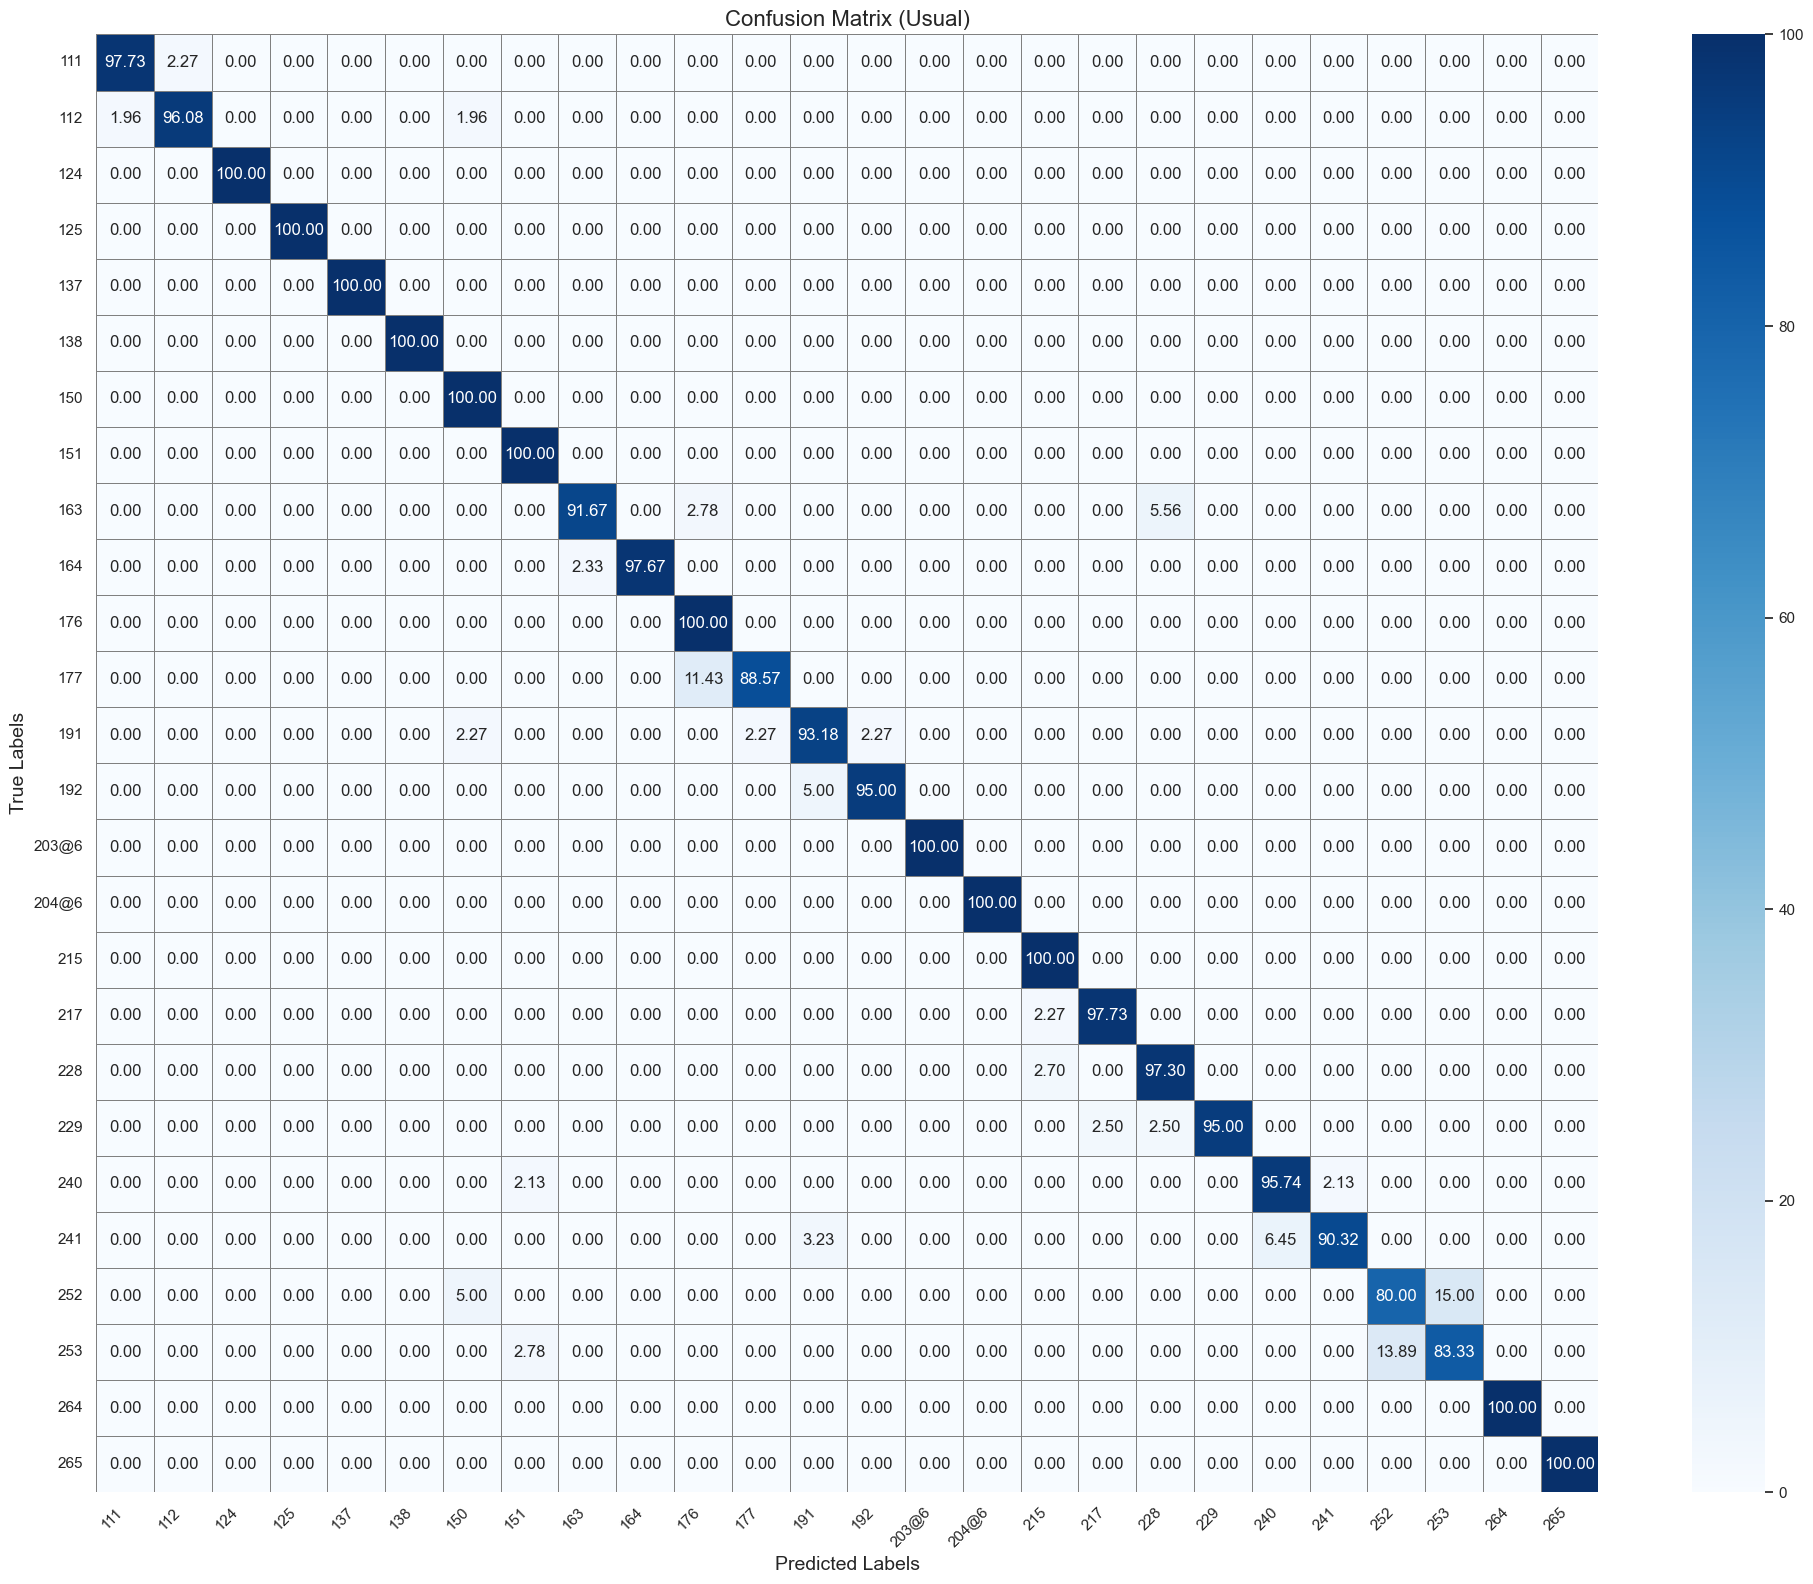

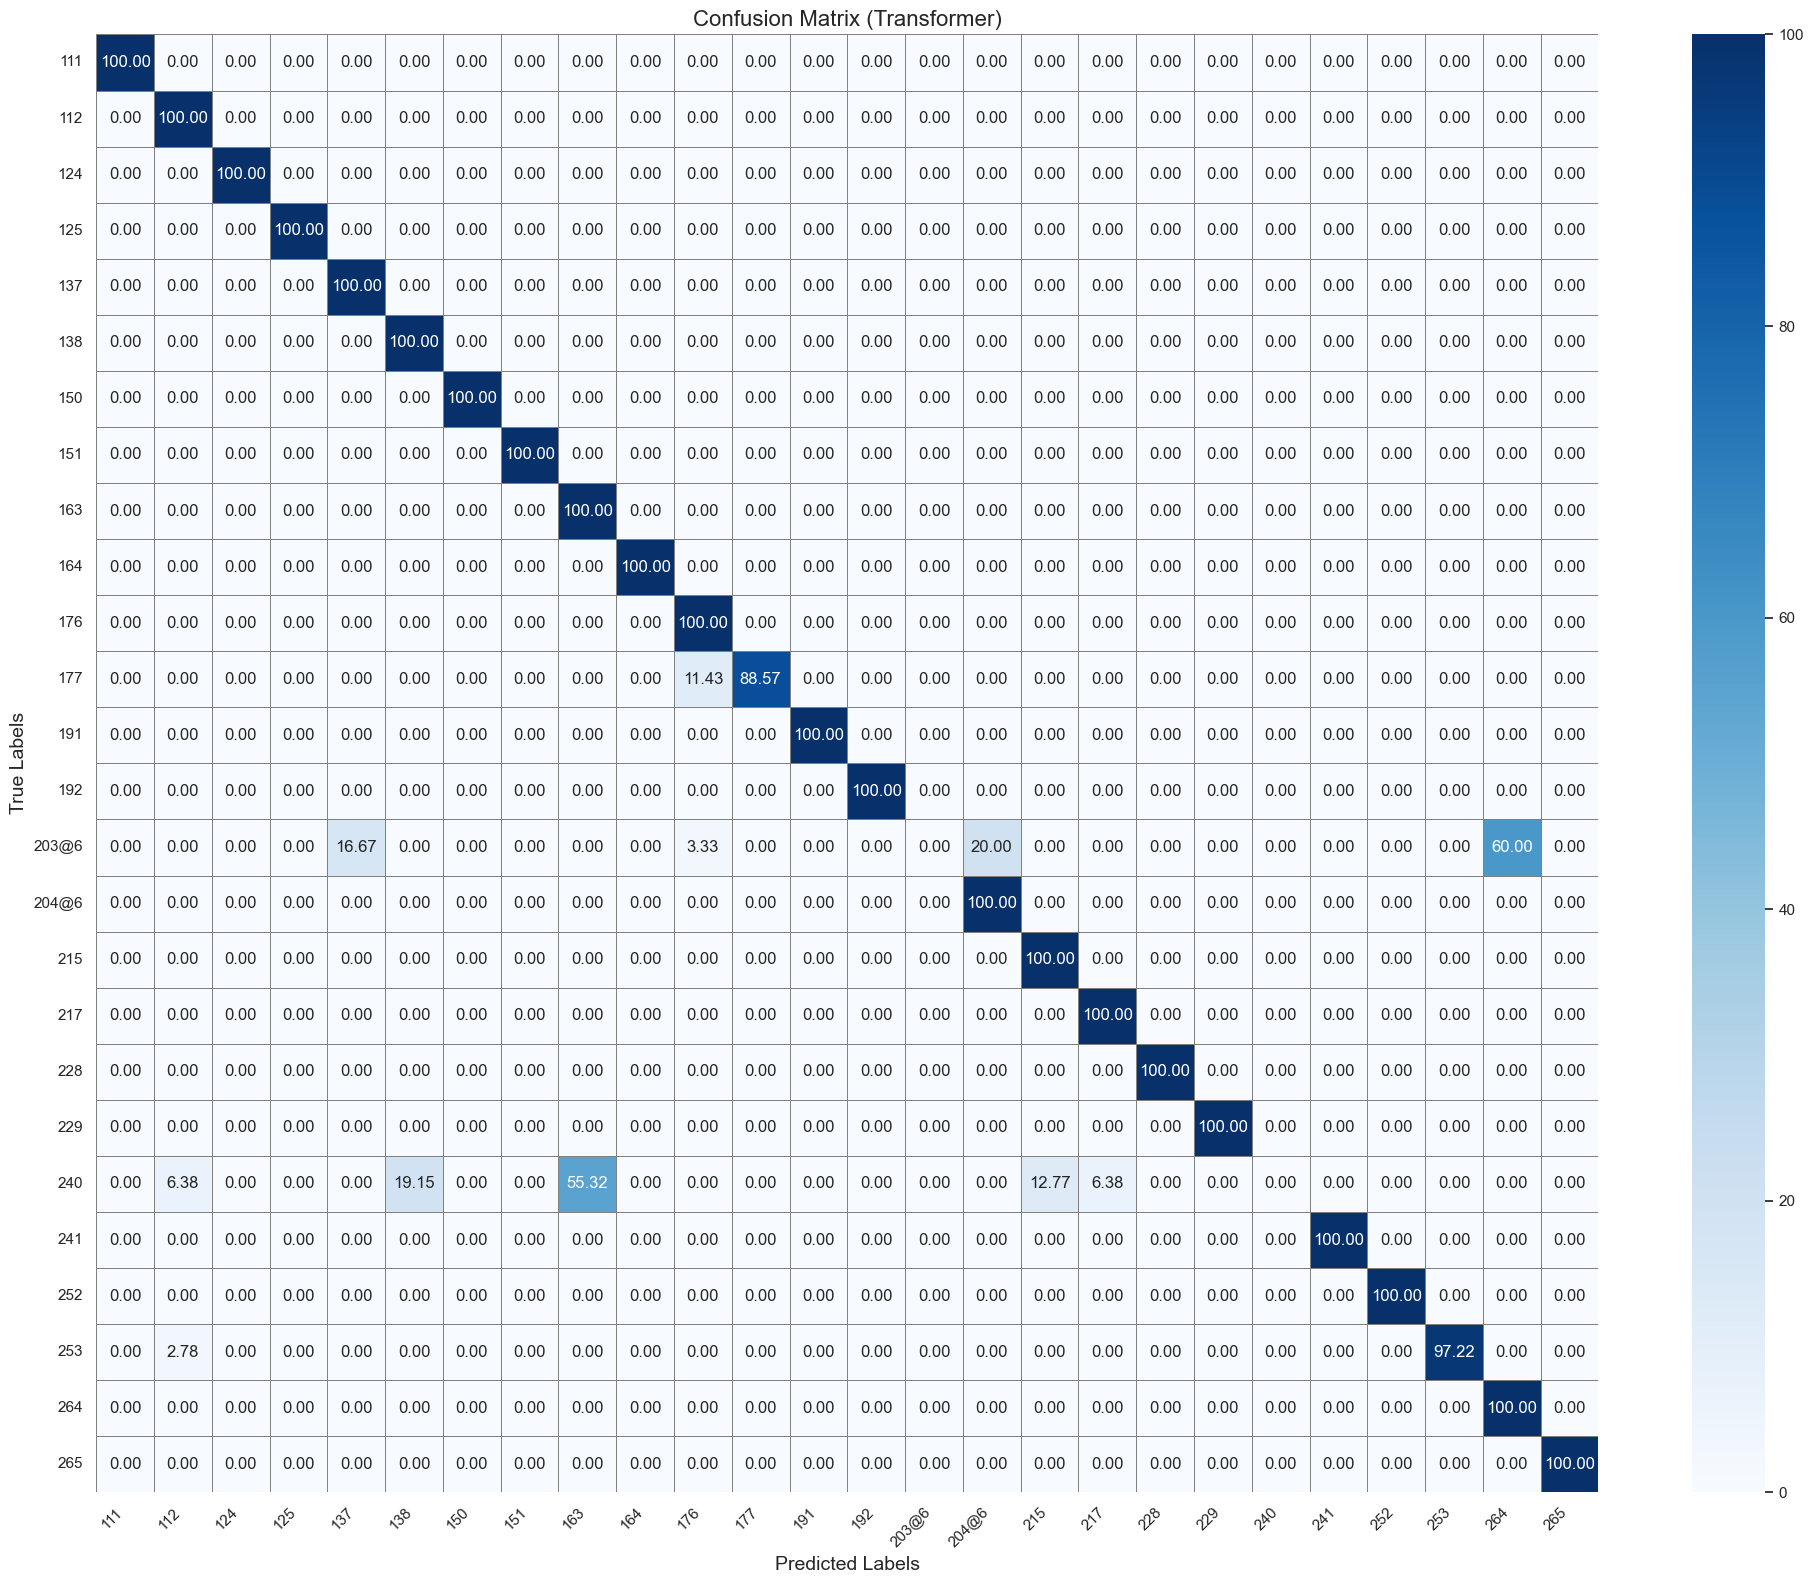

In [10]:
utils.show_cm(r'temp\cm_Usual_Test.txt', dtype='f', title='Usual')
utils.show_cm(r'temp\cm_Trans_Test.txt', dtype='f', title='Transformer')

## GAN

In [6]:
def kl_divergence_builtin(tensor1, tensor2, epsilon=1e-8):
    """
    Calculate KL divergence using PyTorch's built-in KL divergence function.
    """
    assert tensor1.shape == tensor2.shape, "Tensors must have the same shape"
    
    # Add epsilon and normalize
    tensor1_safe = tensor1 + epsilon
    tensor2_safe = tensor2 + epsilon
    
    p = tensor1_safe / tensor1_safe.sum(dim=1, keepdim=True)
    q = tensor2_safe / tensor2_safe.sum(dim=1, keepdim=True)
    
    # Use PyTorch's KL divergence (returns per-sample KL, then take mean)
    kl_div = F.kl_div(torch.log(q), p, reduction='none').sum(dim=1)
    return kl_div.mean()

X, y, X_t, y_t, lm = get_data()
X = X.permute(0,1,3,2)
X_t = X_t.permute(0,1,3,2)


In [7]:


weight_dir = r'F:\thesis\Articles\2nd\mlruns\994478961421787748\5945e3b605184dd4866fcccf6edc6ace\artifacts'
weight_dir = os.path.join(weight_dir,'test_weight.pth')
network = utils.load_model(Network(26), weight_dir)

weight_dir = r'F:\thesis\Articles\2nd\cod\others\aux_weight_1.pth'
# weight_dir = os.path.join(weight_dir,'test_weight.pth')
auxiliary = utils.load_model(
    AuxNet(n_layer=1, in_dim=1024*5, out_dim=1024), 
    weight_dir)

feature_extractor = network.feature_extractor
classifier = network.classifier
# auxiliary = models.AuxNet(n_layer=1, in_dim=1024*5, out_dim=1024)
discriminator = Classifier(num_classes=2)
generator = FeatureExtractor(input_channels=2)


In [8]:

def calc_features_g(batch_data):
    x_fe = batch_data.flatten(0,1)
    x_fe = generator(x_fe)
    x = x_fe.reshape(batch_data.shape[0], batch_data.shape[1], -1)
    return x

batch_data = X
x = calc_features_g(batch_data)
fake_features = x[:,2,:]
batch_data = x.flatten(1,2)
real_features = auxiliary(batch_data)

In [9]:
print(real_features.shape)
print(fake_features.shape)

torch.Size([3940, 1024])
torch.Size([3940, 1024])


In [36]:
print(real_features.mean()), print(real_features.var())
print(fake_features.mean()), print(fake_features.var())

tensor(0.0390, grad_fn=<MeanBackward0>)
tensor(0.0159, grad_fn=<VarBackward0>)
tensor(0.3565, grad_fn=<MeanBackward0>)
tensor(0.4377, grad_fn=<VarBackward0>)


(None, None)

In [31]:
def wasserstein_distance(p, q, epsilon=1e-8):
    """Wasserstein Distance (Earth Mover's Distance)"""
    p_safe = p + epsilon
    q_safe = q + epsilon
    p_norm = p_safe / p_safe.sum(dim=1, keepdim=True)
    q_norm = q_safe / q_safe.sum(dim=1, keepdim=True)
    
    # For 1D distributions, we can use cumulative differences
    p_cdf = torch.cumsum(p_norm, dim=1)
    q_cdf = torch.cumsum(q_norm, dim=1)
    return torch.mean(torch.abs(p_cdf - q_cdf).sum(dim=1))


def kl_divergence(p, q, epsilon=1e-8):
    """Kullback-Leibler Divergence (asymmetric)"""
    p_safe = p + epsilon
    q_safe = q + epsilon
    p_norm = p_safe / p_safe.sum(dim=1, keepdim=True)
    q_norm = q_safe / q_safe.sum(dim=1, keepdim=True)
    return torch.sum(p_norm * torch.log(p_norm / q_norm), dim=1).mean()

def js_divergence(p, q, epsilon=1e-8):
    """Jensen-Shannon Divergence (symmetric)"""
    p_safe = p + epsilon
    q_safe = q + epsilon
    p_norm = p_safe / p_safe.sum(dim=1, keepdim=True)
    q_norm = q_safe / q_safe.sum(dim=1, keepdim=True)
    
    m = 0.5 * (p_norm + q_norm)
    kl_pm = torch.sum(p_norm * torch.log(p_norm / m), dim=1)
    kl_qm = torch.sum(q_norm * torch.log(q_norm / m), dim=1)
    return 0.5 * (kl_pm + kl_qm).mean()

def cosine_distance(p, q):
    """Cosine Distance (1 - cosine similarity)"""
    p_norm = F.normalize(p, p=2, dim=1)
    q_norm = F.normalize(q, p=2, dim=1)
    return 1 - torch.mean(torch.sum(p_norm * q_norm, dim=1))

def euclidean_distance(p, q):
    """Euclidean Distance between distributions"""
    p_norm = p / p.sum(dim=1, keepdim=True)
    q_norm = q / q.sum(dim=1, keepdim=True)
    return torch.mean(torch.norm(p_norm - q_norm, p=2, dim=1))

In [84]:
def add_gaussian_noise(tensor, std=0.05, mean = 2):
    noise = torch.randn_like(tensor) * std + mean
    return tensor + noise

noise_std = 0.05
noise_mean = 0
fake_features_noisy = add_gaussian_noise(fake_features, std=noise_std, mean = noise_mean)
real_features_noisy = add_gaussian_noise(real_features, std=noise_std, mean = noise_mean)

In [ ]:
print(real_features_noisy.mean()), print(real_features_noisy.var())
print(fake_features_noisy.mean()), print(fake_features_noisy.var())

tensor(2.0391, grad_fn=<MeanBackward0>)
tensor(0.0259, grad_fn=<VarBackward0>)
tensor(2.3565, grad_fn=<MeanBackward0>)
tensor(0.4476, grad_fn=<VarBackward0>)


(None, None)

In [80]:
a =  kl_divergence(real_features_noisy,fake_features_noisy)
b =  kl_divergence(real_features,fake_features)

print(a,b)

tensor(nan, grad_fn=<MeanBackward0>) tensor(nan, grad_fn=<MeanBackward0>)


In [85]:
kl_divergence(real_features, real_features_noisy, epsilon=0.02), cosine_distance(real_features, real_features_noisy)

(tensor(nan, grad_fn=<MeanBackward0>), tensor(0.0968, grad_fn=<RsubBackward1>))

In [70]:
a =  cosine_distance(real_features_noisy,fake_features_noisy)
b =  cosine_distance(real_features,fake_features)

print(a,b)

tensor(0.0066, grad_fn=<RsubBackward1>) tensor(0.8358, grad_fn=<RsubBackward1>)


In [74]:
a =  wasserstein_distance(real_features_noisy,fake_features_noisy)
b =  wasserstein_distance(real_features,fake_features)

print(a,b)

tensor(1.8094, grad_fn=<MeanBackward0>) tensor(37.0302, grad_fn=<MeanBackward0>)
